In [18]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

tf.random.set_seed(42)
np.random.seed(42)

from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

Training shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [19]:
x_train = x_train / 255.0
x_test = x_test / 255.0

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [20]:
data_augmentation = keras.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [21]:
model = keras.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=64
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 93ms/step - accuracy: 0.3120 - loss: 1.8807 - val_accuracy: 0.4839 - val_loss: 1.4749
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 89ms/step - accuracy: 0.4811 - loss: 1.4508 - val_accuracy: 0.5269 - val_loss: 1.3383
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 92ms/step - accuracy: 0.5271 - loss: 1.3254 - val_accuracy: 0.5517 - val_loss: 1.2968
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 91ms/step - accuracy: 0.5565 - loss: 1.2576 - val_accuracy: 0.5663 - val_loss: 1.2588
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.5764 - loss: 1.1972 - val_accuracy: 0.5673 - val_loss: 1.2853
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.5896 - loss: 1.1671 - val_accuracy: 0.5889 - val_loss: 1.2178
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.6053 - loss: 1.1245 - val_accuracy: 0.5822 - val_loss: 1.2635
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 89ms/step - accuracy: 0.6127 - loss: 1.1026 - 

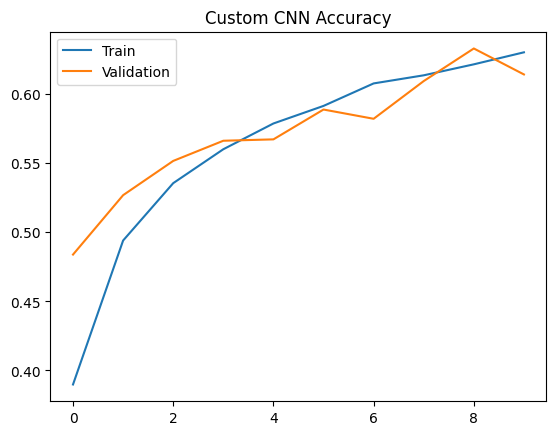

In [23]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Custom CNN Accuracy")
plt.legend(["Train","Validation"])
plt.show()

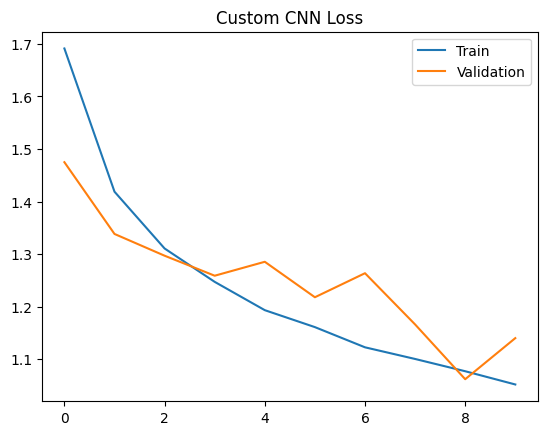

In [24]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Custom CNN Loss")
plt.legend(["Train","Validation"])
plt.show()

In [25]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
              precision    recall  f1-score   support

           0       0.59      0.75      0.66      1000
           1       0.68      0.78      0.72      1000
           2       0.66      0.42      0.51      1000
           3       0.64      0.23      0.34      1000
           4       0.77      0.35      0.48      1000
           5       0.62      0.49      0.55      1000
           6       0.58      0.79      0.67      1000
           7       0.56      0.76      0.64      1000
           8       0.71      0.75      0.73      1000
           9       0.53      0.82      0.64      1000

    accuracy                           0.61     10000
   macro avg       0.63      0.61      0.60     10000
weighted avg       0.63      0.61      0.60     10000



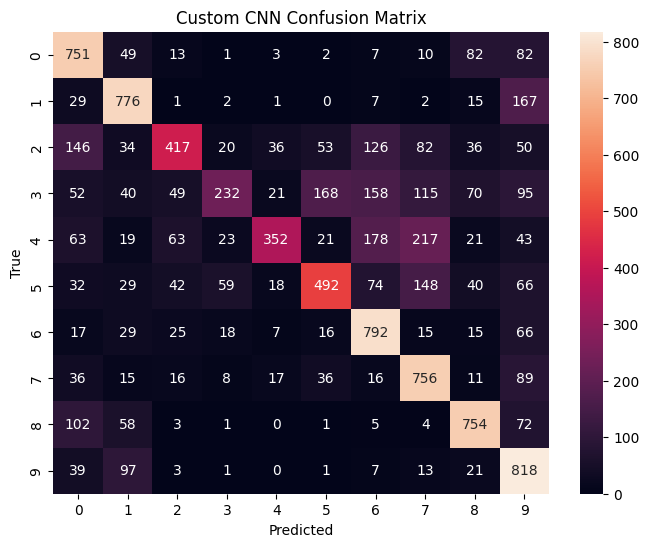

In [26]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Custom CNN Confusion Matrix")
plt.show()

In [9]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(32,32,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

transfer_model = keras.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

transfer_model.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

transfer_model.summary()

/tmp/ipykernel_251/965672425.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,618 (8.93 MB)

 Trainable params: 82,634 (322.79 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
history_transfer = transfer_model.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.2,
    batch_size=64
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 75ms/step - accuracy: 0.2394 - loss: 2.1047 - val_accuracy: 0.3192 - val_loss: 1.8986
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.3171 - loss: 1.8868 - val_accuracy: 0.3276 - val_loss: 1.8704
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - accuracy: 0.3293 - loss: 1.8538 - val_accuracy: 0.3329 - val_loss: 1.8549
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.3363 - loss: 1.8315 - val_accuracy: 0.3382 - val_loss: 1.8434
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - accuracy: 0.3448 - loss: 1.8131 - val_accuracy: 0.3413 - val_loss: 1.8339


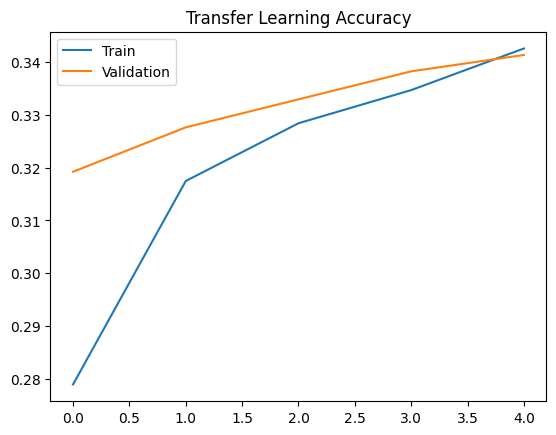

In [11]:
plt.plot(history_transfer.history['accuracy'])
plt.plot(history_transfer.history['val_accuracy'])
plt.title("Transfer Learning Accuracy")
plt.legend(["Train","Validation"])
plt.show()